# 01 — Exploratory Data Analysis

**Purpose.** Eyeball the raw weekly Google Trends search interest for five Vietnamese FMCG categories over 2020–2025 (6 Tet cycles) and answer one foundational question:

> Does the eye see a Tet effect, and which categories show it most clearly?

This notebook is the data check that validates the central premise of the project. If multiple categories show no visible Tet spike, the framework must be reframed around the categories that do.

**Inputs:** `../data/processed/trends_long.csv` produced by `src/load_data.py`.

**Visualization standard.** Per project convention (see `docs/methodology.md`), every chart in this notebook carries:
- A clear, descriptive title
- Axis labels with units
- Vertical-line markers for each year's Tết Mùng 1 (Lunar New Year, day 1)
- An annotation that surfaces the insight

**Proxy caveat.** Read every finding as **search-implied Tet effect**, not as sales Tet effect (see `docs/methodology.md` §5).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_rows', 40)
pd.set_option('display.float_format', '{:.1f}'.format)

In [2]:
ROOT = Path('..').resolve()

df = pd.read_csv(ROOT / 'data' / 'processed' / 'trends_long.csv')
df['week_start'] = pd.to_datetime(df['week_start'])

print(f'Rows:        {len(df):,}')
print(f'Columns:     {list(df.columns)}')
print(f'Keywords:    {sorted(df["keyword"].unique())}')
print(f'Year column: {df["year"].min()}–{df["year"].max()}')
print(f'Date span:   {df["week_start"].min().date()} → {df["week_start"].max().date()}')
df.head()

Rows:        1,590
Columns:     ['keyword', 'keyword_label', 'year', 'week_start', 'search_index', 'below_threshold', 'source_file']
Keywords:    ['banh_keo', 'bia', 'dau_an', 'nuoc_ngot', 'sua']
Year column: 2020–2025
Date span:   2019-12-29 → 2025-12-28


,keyword,keyword_label,year,week_start,search_index,below_threshold,source_file
0,banh_keo,Bánh kẹo (Confectionery),2020,2019-12-29,65.0,False,banh_keo_2020.csv
1,banh_keo,Bánh kẹo (Confectionery),2020,2020-01-05,89.0,False,banh_keo_2020.csv
2,banh_keo,Bánh kẹo (Confectionery),2020,2020-01-12,100.0,False,banh_keo_2020.csv
3,banh_keo,Bánh kẹo (Confectionery),2020,2020-01-19,96.0,False,banh_keo_2020.csv
4,banh_keo,Bánh kẹo (Confectionery),2020,2020-01-26,39.0,False,banh_keo_2020.csv


In [3]:
# Drop year-boundary duplicates: each yearly Google Trends export shares
# one boundary week with the next year's file, but with different per-file
# normalized values. Keep the row from the file whose `year` matches the
# calendar year of `week_start`. See docs/methodology.md §4.6.
df = df[df['week_start'].dt.year == df['year']].copy()

# Gregorian date of Mùng 1 Tết (Lunar Jan 1) for each year in scope.
tet_dates = {
    2020: pd.Timestamp('2020-01-25'),
    2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'),
    2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'),
    2025: pd.Timestamp('2025-01-29'),
}

print(f'Rows after dedup: {len(df):,}')

Rows after dedup: 1,565


## Time-series overview — five categories vs Tết Mùng 1

Five panels, one per keyword, showing weekly Google Trends search interest for Vietnam over 2020–2025. Dashed red vertical lines mark Mùng 1 Tết each year. Each panel carries an annotation calling out the headline observation.

Categories are ordered top-to-bottom by Tet-effect strength (strongest first), based on the uplift metrics tabulated in the next section.

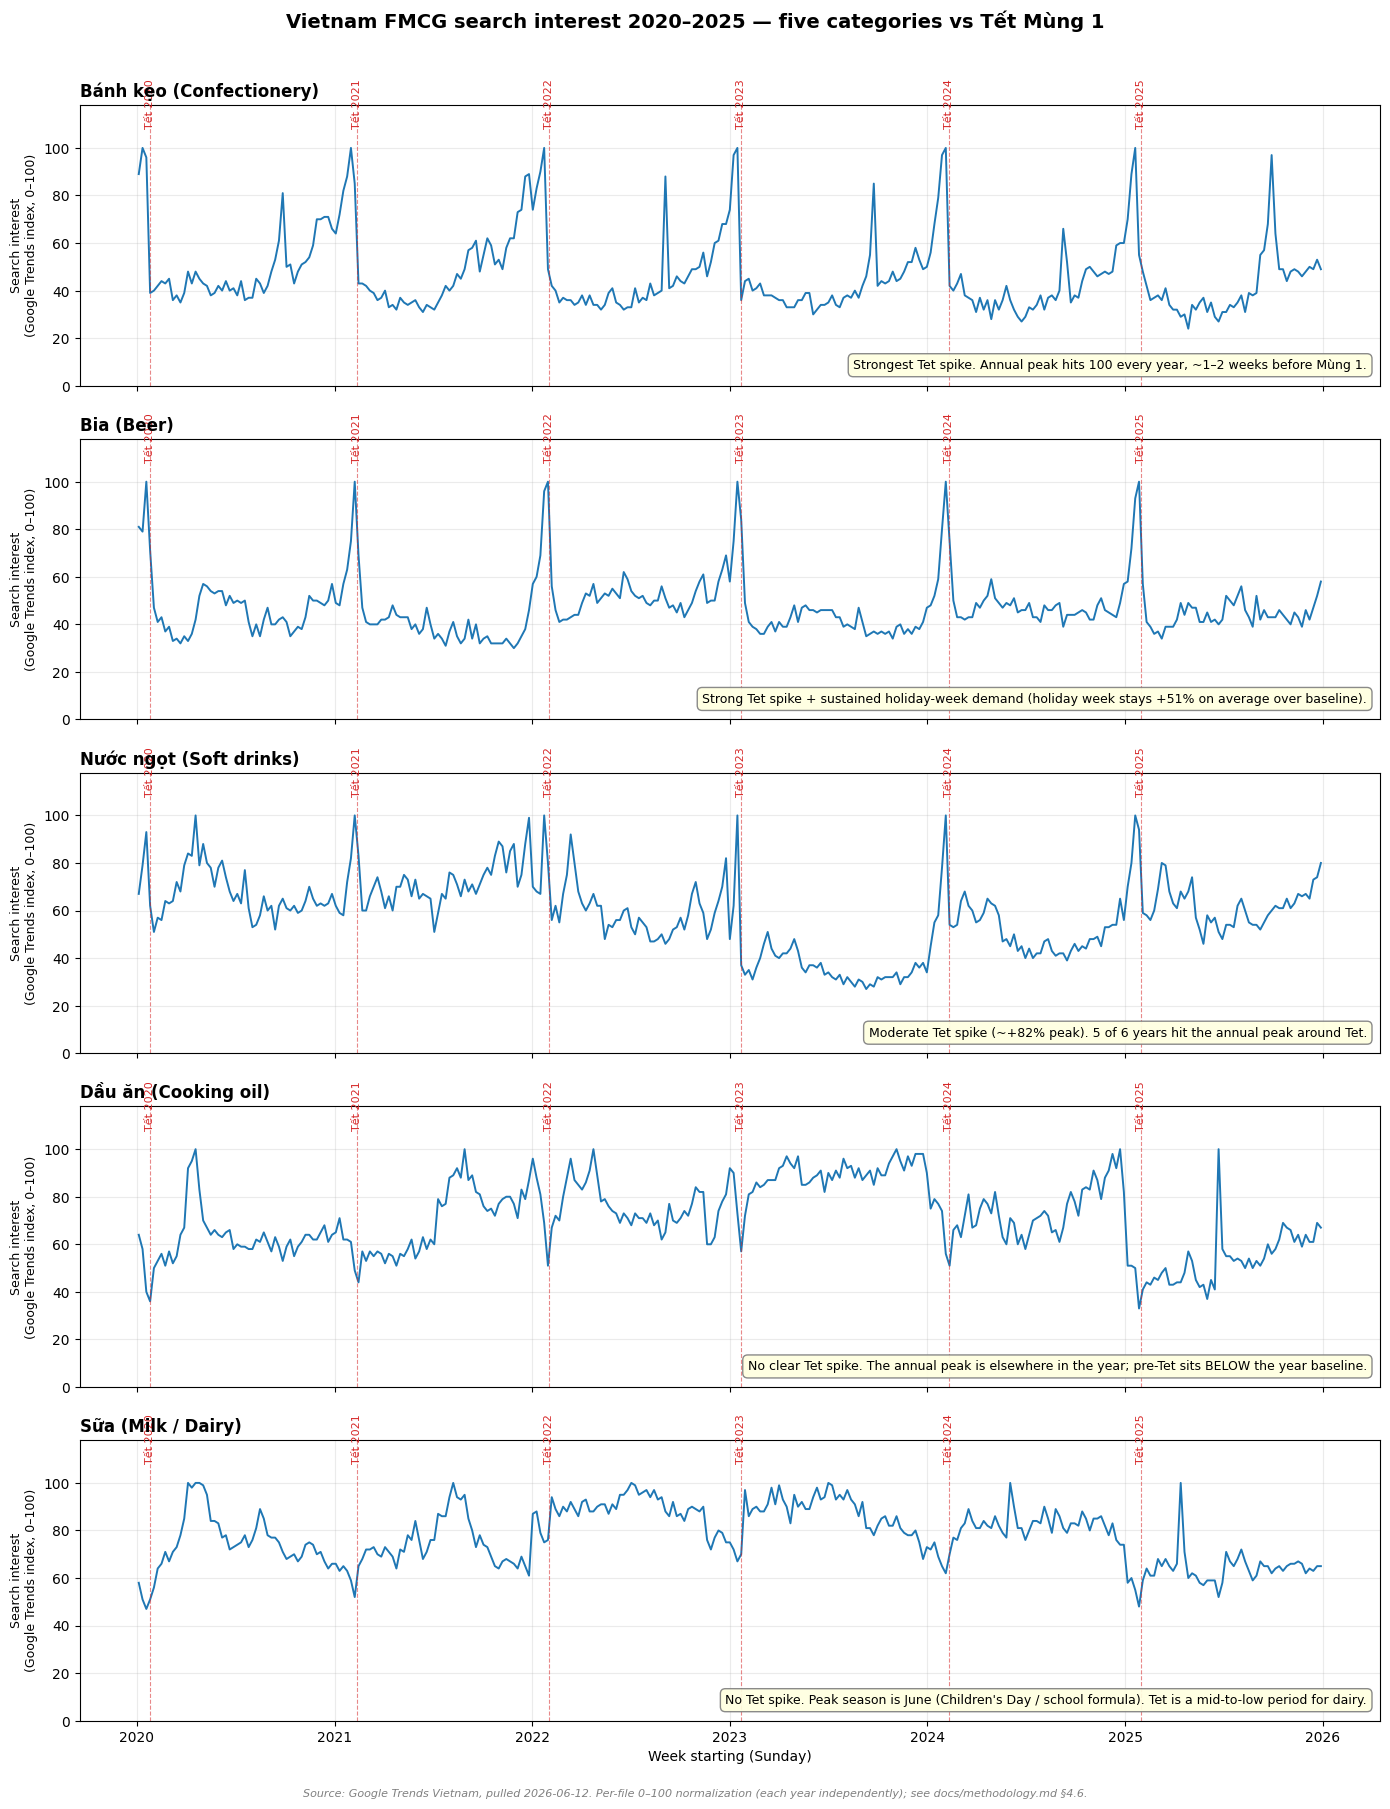

In [4]:
keyword_order = ['banh_keo', 'bia', 'nuoc_ngot', 'dau_an', 'sua']
labels = {
    'banh_keo':  'Bánh kẹo (Confectionery)',
    'bia':       'Bia (Beer)',
    'nuoc_ngot': 'Nước ngọt (Soft drinks)',
    'dau_an':    'Dầu ăn (Cooking oil)',
    'sua':       'Sữa (Milk / Dairy)',
}
annotations = {
    'banh_keo':  'Strongest Tet spike. Annual peak hits 100 every year, ~1–2 weeks before Mùng 1.',
    'bia':       'Strong Tet spike + sustained holiday-week demand (holiday week stays +51% on average over baseline).',
    'nuoc_ngot': 'Moderate Tet spike (~+82% peak). 5 of 6 years hit the annual peak around Tet.',
    'dau_an':    'No clear Tet spike. The annual peak is elsewhere in the year; pre-Tet sits BELOW the year baseline.',
    'sua':       "No Tet spike. Peak season is June (Children's Day / school formula). Tet is a mid-to-low period for dairy.",
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, kw in zip(axes, keyword_order):
    g = df[df['keyword'] == kw].sort_values('week_start')
    ax.plot(g['week_start'], g['search_index'], color='#1f77b4', linewidth=1.4)

    for year, t in tet_dates.items():
        ax.axvline(t, color='#d62728', linestyle='--', linewidth=0.8, alpha=0.55)
        ax.text(t, 108, f'Tết {year}', rotation=90, fontsize=8,
                ha='center', va='bottom', color='#d62728')

    ax.set_ylim(0, 118)
    ax.set_ylabel('Search interest\n(Google Trends index, 0–100)', fontsize=9)
    ax.set_title(labels[kw], fontsize=12, loc='left', pad=6, fontweight='bold')
    ax.grid(True, alpha=0.25)

    ax.text(
        0.99, 0.05, annotations[kw],
        transform=ax.transAxes,
        fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.92),
    )

axes[-1].set_xlabel('Week starting (Sunday)', fontsize=10)

fig.suptitle(
    'Vietnam FMCG search interest 2020–2025 — five categories vs Tết Mùng 1',
    fontsize=14, fontweight='bold', y=0.998,
)
fig.text(
    0.5, 0.005,
    'Source: Google Trends Vietnam, pulled 2026-06-12. '
    'Per-file 0–100 normalization (each year independently); see docs/methodology.md §4.6.',
    ha='center', fontsize=8, style='italic', color='gray',
)

plt.tight_layout(rect=[0, 0.015, 1, 0.99])

# Save a copy for reuse in the white paper / LinkedIn drafts.
fig_dir = ROOT / 'notebooks' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / '01_eda_overview.png', dpi=120, bbox_inches='tight')

plt.show()

## Tet uplift metrics

For each `(keyword, year)` cell, compute four metrics defined in `docs/methodology.md` §4:

- **Pre-Tet uplift %** — mean search index in the 6-week pre-Tet window divided by the within-year baseline (the rest of the year, excluding the holiday and recovery windows).
- **Peak uplift %** — same comparison but for the single highest week inside the pre-Tet window.
- **Peak T−minus weeks** — how many weeks before Mùng 1 the peak actually lands.
- **Holiday dip %** — mean search index in the Tet holiday week (T to T+7d) vs the within-year baseline. Negative = demand drops during the holiday.

All four metrics are within-year ratios over a within-year baseline, which makes them **scale-invariant under the per-file 0–100 normalization** (see methodology §4.6). They are valid across keywords AND across years even though raw `search_index` levels are not.

In [5]:
def compute_metrics(group: pd.DataFrame, year: int) -> dict:
    tet = tet_dates[year]
    pre = group[(group['week_start'] >= tet - pd.Timedelta(weeks=6))
                & (group['week_start'] < tet)]
    holiday = group[(group['week_start'] >= tet)
                    & (group['week_start'] < tet + pd.Timedelta(days=8))]
    base = group[(group['week_start'] < tet - pd.Timedelta(weeks=6))
                 | (group['week_start'] >= tet + pd.Timedelta(weeks=4))]
    base_mean = base['search_index'].mean()
    peak_idx = pre['search_index'].idxmax() if not pre.empty else None
    peak_week = pre.loc[peak_idx, 'week_start'] if peak_idx is not None else None
    weeks_before = (tet - peak_week).days / 7 if peak_week is not None else None
    return {
        'pre_tet_uplift_%':   round((pre['search_index'].mean() / base_mean - 1) * 100, 1),
        'peak_uplift_%':      round((pre['search_index'].max() / base_mean - 1) * 100, 1),
        'peak_T_minus_weeks': round(weeks_before, 1) if weeks_before is not None else None,
        'holiday_dip_%':      round((holiday['search_index'].mean() / base_mean - 1) * 100, 1) if not holiday.empty else None,
    }

rows = []
for (kw, yr), g in df.groupby(['keyword', 'year']):
    rows.append({'keyword': kw, 'year': yr, **compute_metrics(g, yr)})

metrics_df = pd.DataFrame(rows).set_index(['keyword', 'year'])
metrics_df

pre_tet_uplift_%  peak_uplift_%  peak_T_minus_weeks  \
keyword   year                                                        
banh_keo  2020              98.9          109.4                 1.9   
          2021              72.9          111.3                 1.7   
          2022              84.1          132.4                 1.3   
          2023             117.0          140.2                 1.0   
          2024              99.1          148.8                 0.9   
          2025              88.9          140.7                 1.4   
bia       2020              95.7          125.8                 0.9   
          2021              74.4          167.0                 0.7   
          2022              47.9           93.6                 0.3   
          2023              91.5          146.5                 1.0   
          2024              45.5          114.6                 0.9   
          2025              81.6          124.8                 0.4   
dau_an    2020             -15.6            0.0                 2.9   
          2021             -13.8           -0.8                 4.7   
          2022               1.5           26.5                 4.3   
          2023              -6.4            1.3                 3.0   
          2024              -4.2            4.8                 3.9   
          2025             -15.6           -7.0                 3.4   
nuoc_ngot 2020              17.3           37.0                 0.9   
          2021              -0.2           38.3                 0.7   
          2022              30.3           69.2                 1.3   
          2023              97.8          182.6                 1.0   
          2024              34.9          100.7                 0.9   
          2025              39.1           61.8                 1.4   
sua       2020             -33.2          -25.4                 2.9   
          2021             -18.5          -12.3                 5.7   
          2022              -9.2           -1.3                 3.3   
          2023             -18.8          -14.6                 3.0   
          2024             -17.2           -9.4                 3.9   
          2025             -14.5           -7.2                 2.4   

                holiday_dip_%  
keyword   year                 
banh_keo  2020          -18.3  
          2021           -9.2  
          2022           -2.4  
          2023           -3.9  
          2024            4.5  
          2025           15.5  
bia       2020           60.3  
          2021           84.2  
          2022            8.4  
          2023           63.9  
          2024           60.9  
          2025           28.2  
dau_an    2020          -43.8  
          2021          -38.5  
          2022          -11.7  
          2023          -29.0  
          2024          -32.3  
          2025          -25.2  
nuoc_ngot 2020           -8.7  
          2021           14.8  
          2022           -5.3  
          2023           -1.1  
          2024            8.4  
          2025           -4.6  
sua       2020          -34.4  
          2021          -13.6  
          2022            5.4  
          2023           -4.9  
          2024          -15.5  
          2025           -8.7

In [6]:
# 6-year mean per keyword, ranked by peak uplift
summary = (
    metrics_df
    .groupby('keyword')[['pre_tet_uplift_%', 'peak_uplift_%', 'peak_T_minus_weeks', 'holiday_dip_%']]
    .mean()
    .round(1)
    .sort_values('peak_uplift_%', ascending=False)
)
summary

,pre_tet_uplift_%,peak_uplift_%,peak_T_minus_weeks,holiday_dip_%
keyword,,,,
banh_keo,93.5,130.5,1.4,-2.3
bia,72.8,128.7,0.7,51.0
nuoc_ngot,36.5,81.6,1.0,0.6
dau_an,-9.0,4.1,3.7,-30.1
sua,-18.6,-11.7,3.5,-12.0


## Findings

### 1. The Tet Effect is real and strong for 3 of 5 categories

`bánh kẹo` (confectionery), `bia` (beer), and `nước ngọt` (soft drinks) all show a clear, repeatable spike around Tet:

| Category | Mean peak uplift | Peak timing | Holiday-week behavior |
|----------|------------------|-------------|-----------------------|
| Bánh kẹo (confectionery) | **+130%** | T−1.4 weeks | Slight dip (−2%) |
| Bia (beer)               | **+129%** | T−0.7 weeks | **Stays elevated, +51%** |
| Nước ngọt (soft drinks)  | **+82%**  | T−1.0 week  | Roughly flat (+1%) |

For all three, the **annual peak (search index = 100) lands inside the pre-Tet window** in 5 or 6 of the 6 years studied. This confirms the project premise — Vietnamese FMCG demand has a quantifiable, public, per-category Tet pattern.

### 2. Two categories show NO Tet spike — `dầu ăn` and `sữa`

The surprise. Both categories' pre-Tet window sits *below* the within-year baseline:

- **Dầu ăn (cooking oil):** pre-Tet mean is **−9%** below baseline. Even the highest week in the pre-Tet window is only +4% above baseline — well within noise. The annual peak occurs elsewhere in the year (likely Q4, before winter cooking season).
- **Sữa (milk / dairy):** pre-Tet mean is **−19%** below baseline. The annual peak occurs in **June** — almost certainly tied to Children's Day (1 June), school-holiday shopping, and infant-formula seasonality. Tet is a *mid-to-low* search period for dairy.

This does **not** mean Tet hurts demand for these categories. It means Tet is not the demand event that drives their annual peak. The search-implied baseline is pulled up by other higher-search seasons elsewhere in the year, which is why Tet weeks register as *below* baseline.

### 3. Peak timing is closer to Tet than the planner heuristic suggests

The widely-cited planner heuristic is *"x2 demand four weeks before Tet."* The data says the weekly peak actually lands at **T−1 to T−2 weeks** for the three Tet-sensitive categories — much closer to Tet itself than four weeks out. The four-week heuristic likely refers to when elevated demand *starts*, not when it peaks.

This is a candidate headline finding for LinkedIn Post 2.

### 4. Beer behaves differently during the holiday week

Confectionery dips slightly during the Tet holiday window itself (people have already stocked up). Beer instead stays elevated or goes higher (**+51% above baseline on average**) — the *consumption* peak, not the *stocking* peak, lands on the holiday itself.

This shape difference matters for replenishment planning: confectionery is a pre-stock category, beer has both pre-stock and within-holiday demand.

## Implications for the framework

- **Reframe the cross-category story:** "Tet effect is concentrated in **beverages and confectionery**, not blanket across FMCG."
- **For `dầu ăn` and `sữa`:** report **"no detected Tet spike — peak season lies elsewhere"** as a publishable, non-obvious finding rather than forcing a quantitative Tet uplift number.
- **Peak timing (T−1w to T−2w, not T−4w):** directly challenges the standing planner heuristic. Candidate headline for LinkedIn Post 2.

## Next steps (Week 3)

- Implement formal time-series decomposition (statsmodels STL) to separate trend, seasonal, and residual components, then re-derive uplift on the seasonal component only.
- Quantify holiday-week dip-vs-spike pattern more rigorously per category.
- Generate per-category publication-quality figures (one figure per category) for the white paper.